# 06. Riesgo condicional de sequía mediante cópulas (nSPEI-3)

Versión corregida y trazable con los resultados definitivos de los Bloques 03 y 04.

El cuaderno:

1. lee los eventos nSPEI-3;
2. lee las marginales MLE seleccionadas en el Bloque 03;
3. lee la cópula seleccionada en el Bloque 04;
4. verifica automáticamente los modelos finales:
   - Cluster 1: LN3 / LN3 / Gaussiana;
   - Cluster 2: LN3 / LN3 / Gumbel;
   - Cluster 3: LN3 / GPA / Gumbel;
5. calcula
   $$
   P(S>s\mid D>d)
   =
   \frac{P(D>d,S>s)}{P(D>d)}
   $$
   y
   $$
   P(D>d\mid S>s)
   =
   \frac{P(D>d,S>s)}{P(S>s)};
  $$
6. evalúa las combinaciones P50, P75 y P90;
7. genera tablas y superficies condicionales;
8. ejecuta controles numéricos para verificar que todas las probabilidades estén entre 0 y 1.

Nota conceptual: en este bloque se estima **probabilidad condicional de excedencia**. El término “riesgo condicional” se conserva por consistencia con la tesis, pero no implica por sí solo consecuencias, exposición o vulnerabilidad.


In [1]:
# ============================================================
# 1. LIBRERÍAS
# ============================================================

if (!require("pacman")) install.packages("pacman")

pacman::p_load(
  tidyverse,
  janitor,
  lmomco,
  copula,
  patchwork,
  metR,
  scales
)


Cargando paquete requerido: pacman

Warning message:
"package 'pacman' was built under R version 4.5.3"


In [2]:
# ============================================================
# 2. RUTAS DEL PROYECTO
# ============================================================

encontrar_raiz_proyecto <- function(inicio = getwd()) {
  marcadores <- c("01_datos", "02_scripts", "03_resultados", "04_documentacion")
  es_raiz <- function(x) all(dir.exists(file.path(x, marcadores)))

  raiz_env <- Sys.getenv("TESIS_SEQUIAS_ROOT", unset = "")
  if (nzchar(raiz_env)) {
    raiz_env <- normalizePath(raiz_env, winslash = "/", mustWork = FALSE)
    if (es_raiz(raiz_env)) return(raiz_env)
  }

  ruta <- normalizePath(inicio, winslash = "/", mustWork = TRUE)

  repeat {
    if (es_raiz(ruta)) return(ruta)

    padre <- dirname(ruta)
    if (identical(padre, ruta)) {
      stop(
        "No se encontró la raíz del proyecto. ",
        "Ejecute Jupyter dentro del repositorio o defina TESIS_SEQUIAS_ROOT."
      )
    }

    ruta <- padre
  }
}

ruta_base <- encontrar_raiz_proyecto()

ruta_procesados <- file.path(
  ruta_base, "01_datos", "procesados"
)

ruta_marginales <- file.path(
  ruta_base, "03_resultados", "03_marginales", "tablas"
)

ruta_copulas <- file.path(
  ruta_base, "03_resultados", "04_copulas", "tablas"
)

ruta_tablas <- file.path(
  ruta_base, "03_resultados", "06_riesgo_condicional", "tablas"
)

ruta_figuras <- file.path(
  ruta_base, "03_resultados", "06_riesgo_condicional", "figuras"
)

archivo_eventos <- file.path(
  ruta_procesados,
  "eventos_nspei_todas_escalas.csv"
)

archivo_marginales <- file.path(
  ruta_marginales,
  "mejores_marginales_nspei3_por_cluster.csv"
)

archivo_copulas <- file.path(
  ruta_copulas,
  "copulas_seleccionadas_nspei3.csv"
)

dir.create(ruta_tablas, recursive = TRUE, showWarnings = FALSE)
dir.create(ruta_figuras, recursive = TRUE, showWarnings = FALSE)

cat("Eventos:", file.exists(archivo_eventos), "\n")
cat("Marginales:", file.exists(archivo_marginales), "\n")
cat("Cópulas:", file.exists(archivo_copulas), "\n")
cat("Ruta tablas:", ruta_tablas, "\n")
cat("Ruta figuras:", ruta_figuras, "\n")

if (!file.exists(archivo_eventos)) {
  stop("No se encontró el archivo de eventos.")
}

if (!file.exists(archivo_marginales)) {
  stop("No se encontró el archivo de marginales finales del Bloque 03.")
}

if (!file.exists(archivo_copulas)) {
  stop("No se encontró el archivo de cópulas seleccionadas del Bloque 04.")
}


Eventos: TRUE 
Marginales: TRUE 
Cópulas: TRUE 
Ruta tablas: D:/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/06_riesgo_condicional/tablas 
Ruta figuras: D:/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/06_riesgo_condicional/figuras 


In [3]:
# ============================================================
# 3. LECTURA Y VERIFICACIÓN DE LOS MODELOS FINALES
# ============================================================

eventos <- read.csv(
  archivo_eventos,
  stringsAsFactors = FALSE
) %>%
  clean_names() %>%
  mutate(
    fecha_inicio = as.Date(fecha_inicio),
    fecha_fin = as.Date(fecha_fin),
    cluster_ward = as.integer(cluster_ward)
  )

eventos_3 <- eventos %>%
  filter(escala == "nspei_3") %>%
  filter(
    is.finite(duracion),
    is.finite(severidad),
    duracion > 0,
    severidad > 0
  )

marginales_finales <- read.csv(
  archivo_marginales,
  stringsAsFactors = FALSE,
  check.names = FALSE
) %>%
  clean_names() %>%
  mutate(
    cluster = as.integer(stringr::str_extract(grupo, "\\d+")),
    variable_clave = if_else(
      stringr::str_detect(variable, regex("Duraci", ignore_case = TRUE)),
      "D",
      "S"
    ),
    modelo = toupper(modelo)
  )

copulas_finales <- read.csv(
  archivo_copulas,
  stringsAsFactors = FALSE,
  check.names = FALSE
) %>%
  clean_names() %>%
  mutate(
    cluster = as.integer(cluster),
    familia = as.character(familia)
  )

esperado_marginal <- tibble(
  cluster = c(1, 1, 2, 2, 3, 3),
  variable_clave = c("D", "S", "D", "S", "D", "S"),
  modelo_esperado = c("LN3", "LN3", "LN3", "LN3", "LN3", "GPA")
)

verificacion_marginal <- marginales_finales %>%
  select(cluster, variable_clave, modelo) %>%
  left_join(
    esperado_marginal,
    by = c("cluster", "variable_clave")
  ) %>%
  mutate(
    coincide = modelo == modelo_esperado
  )

esperado_copula <- tibble(
  cluster = 1:3,
  familia_esperada = c("Gaussian", "Gumbel", "Gumbel")
)

verificacion_copula <- copulas_finales %>%
  select(cluster, familia, convergio, coincide_aic_bic) %>%
  left_join(
    esperado_copula,
    by = "cluster"
  ) %>%
  mutate(
    coincide = familia == familia_esperada
  )

cat("\n=== VERIFICACIÓN DE MARGINALES ===\n")
print(verificacion_marginal)

cat("\n=== VERIFICACIÓN DE CÓPULAS ===\n")
print(verificacion_copula)

if (any(is.na(verificacion_marginal$coincide) | !verificacion_marginal$coincide)) {
  stop("Las marginales no coinciden con los resultados definitivos del Bloque 03.")
}

if (
  any(is.na(verificacion_copula$coincide) | !verificacion_copula$coincide) ||
  any(!verificacion_copula$convergio) ||
  any(!verificacion_copula$coincide_aic_bic)
) {
  stop("Las cópulas no coinciden con los resultados definitivos del Bloque 04.")
}



=== VERIFICACIÓN DE MARGINALES ===
  cluster variable_clave modelo modelo_esperado coincide
1       1              D    LN3             LN3     TRUE
2       1              S    LN3             LN3     TRUE
3       2              D    LN3             LN3     TRUE
4       2              S    LN3             LN3     TRUE
5       3              D    LN3             LN3     TRUE
6       3              S    GPA             GPA     TRUE

=== VERIFICACIÓN DE CÓPULAS ===
  cluster  familia convergio coincide_aic_bic familia_esperada coincide
1       1 Gaussian      TRUE             TRUE         Gaussian     TRUE
2       2   Gumbel      TRUE             TRUE           Gumbel     TRUE
3       3   Gumbel      TRUE             TRUE           Gumbel     TRUE


In [4]:
# ============================================================
# 4. RECONSTRUCCIÓN DE MARGINALES Y CÓPULAS
# ============================================================

parsear_parametros_marginal <- function(x) {
  as.numeric(trimws(strsplit(x, ",", fixed = TRUE)[[1]]))
}

obtener_marginal <- function(cluster, variable_clave) {

  fila <- marginales_finales %>%
    filter(
      .data$cluster == .env$cluster,
      .data$variable_clave == .env$variable_clave
    )

  if (nrow(fila) != 1) {
    stop(
      "No se encontró exactamente una marginal para cluster ",
      cluster, " y variable ", variable_clave
    )
  }

  tipo <- tolower(fila$modelo[[1]])
  pars <- parsear_parametros_marginal(fila$parametros[[1]])

  list(
    modelo = toupper(tipo),
    parametros = pars,
    par_obj = lmomco::vec2par(pars, type = tipo)
  )
}

parsear_parametros_copula <- function(x) {

  piezas <- strsplit(x, ";", fixed = TRUE)[[1]]

  valores <- vapply(
    piezas,
    function(z) {
      partes <- strsplit(z, "=", fixed = TRUE)[[1]]
      if (length(partes) < 2) return(NA_real_)
      as.numeric(trimws(partes[length(partes)]))
    },
    numeric(1)
  )

  if (any(!is.finite(valores))) {
    stop("No se pudieron interpretar los parámetros de la cópula: ", x)
  }

  valores
}

obtener_copula <- function(cluster) {

  fila <- copulas_finales %>%
    filter(.data$cluster == .env$cluster)

  if (nrow(fila) != 1) {
    stop("No se encontró exactamente una cópula para el cluster ", cluster)
  }

  familia <- fila$familia[[1]]
  pars <- parsear_parametros_copula(fila$parametro[[1]])

  cop <- switch(
    tolower(familia),

    "gaussian" = normalCopula(
      param = pars[1],
      dim = 2,
      dispstr = "un"
    ),

    "gumbel" = gumbelCopula(
      param = pars[1],
      dim = 2
    ),

    "clayton" = claytonCopula(
      param = pars[1],
      dim = 2
    ),

    "frank" = frankCopula(
      param = pars[1],
      dim = 2
    ),

    "t-student" = tCopula(
      param = pars[1],
      dim = 2,
      dispstr = "un",
      df = pars[2],
      df.fixed = TRUE
    ),

    stop("Familia de cópula no implementada: ", familia)
  )

  list(
    familia = familia,
    parametro_texto = fila$parametro[[1]],
    parametros = pars,
    copula = cop
  )
}

modelos_cluster <- lapply(
  1:3,
  function(cl) {
    list(
      cluster = cl,
      D = obtener_marginal(cl, "D"),
      S = obtener_marginal(cl, "S"),
      C = obtener_copula(cl)
    )
  }
)

tabla_modelos_finales <- map_dfr(
  modelos_cluster,
  function(m) {
    tibble(
      cluster = m$cluster,
      marginal_duracion = m$D$modelo,
      marginal_severidad = m$S$modelo,
      copula = m$C$familia,
      parametro_copula = m$C$parametro_texto
    )
  }
)

cat("\n=== MODELOS FINALES UTILIZADOS ===\n")
print(tabla_modelos_finales, n = Inf, width = Inf)



=== MODELOS FINALES UTILIZADOS ===
# A tibble: 3 × 5
  cluster marginal_duracion marginal_severidad copula   parametro_copula
    <int> <chr>             <chr>              <chr>    <chr>           
1       1 LN3               LN3                Gaussian rho.1=0.903663  
2       2 LN3               LN3                Gumbel   alpha=3.456922  
3       3 LN3               GPA                Gumbel   alpha=3.801567  


In [5]:
# ============================================================
# 5. FUNCIONES DE PROBABILIDAD CONDICIONAL
# ============================================================

cdf_marginal <- function(x, par_obj, eps = 1e-8) {

  p <- lmomco::plmomco(x, par_obj)

  if (any(!is.finite(p))) {
    stop("Se obtuvieron valores no finitos en una CDF marginal.")
  }

  pmin(pmax(p, eps), 1 - eps)
}

prob_excedencia_conjunta <- function(
  d, s,
  par_d, par_s,
  copula_obj
) {

  u <- cdf_marginal(d, par_d)
  v <- cdf_marginal(s, par_s)

  Cuv <- copula::pCopula(
    cbind(u, v),
    copula_obj
  )

  p_joint <- 1 - u - v + Cuv
  p_d <- 1 - u
  p_s <- 1 - v

  p_joint <- pmin(pmax(p_joint, 0), 1)
  p_d <- pmin(pmax(p_d, 0), 1)
  p_s <- pmin(pmax(p_s, 0), 1)

  tibble(
    d = d,
    s = s,
    u = u,
    v = v,
    Cuv = Cuv,
    p_joint = p_joint,
    p_d = p_d,
    p_s = p_s
  )
}

riesgo_condicional <- function(
  d, s,
  par_d, par_s,
  copula_obj,
  eps_prob = 1e-15
) {

  prob_excedencia_conjunta(
    d = d,
    s = s,
    par_d = par_d,
    par_s = par_s,
    copula_obj = copula_obj
  ) %>%
    mutate(
      # P(S > s | D > d)
      p_s_d = p_joint / pmax(p_d, eps_prob),

      # P(D > d | S > s)
      p_d_s = p_joint / pmax(p_s, eps_prob),

      p_s_d = pmin(pmax(p_s_d, 0), 1),
      p_d_s = pmin(pmax(p_d_s, 0), 1)
    )
}


In [6]:
# ============================================================
# 6. CÁLCULO P50-P75-P90 POR CLUSTER
# ============================================================

procesar_cluster_condicional <- function(
  datos_cluster,
  cluster_id,
  modelo_cluster
) {

  perc_d <- quantile(
    datos_cluster$duracion,
    probs = c(0.50, 0.75, 0.90),
    na.rm = TRUE,
    type = 7
  )

  perc_s <- quantile(
    datos_cluster$severidad,
    probs = c(0.50, 0.75, 0.90),
    na.rm = TRUE,
    type = 7
  )

  niveles <- c("P50", "P75", "P90")

  tabla_d <- tibble(
    percentil_d = niveles,
    d = as.numeric(perc_d)
  )

  tabla_s <- tibble(
    percentil_s = niveles,
    s = as.numeric(perc_s)
  )

  grid <- tidyr::crossing(
    tabla_d,
    tabla_s
  )

  probs <- riesgo_condicional(
    d = grid$d,
    s = grid$s,
    par_d = modelo_cluster$D$par_obj,
    par_s = modelo_cluster$S$par_obj,
    copula_obj = modelo_cluster$C$copula
  )

  bind_cols(
    grid,
    probs %>%
      select(
        u, v, Cuv,
        p_joint, p_d, p_s,
        p_s_d, p_d_s
      )
  ) %>%
    mutate(
      cluster = cluster_id,
      dist_d = modelo_cluster$D$modelo,
      dist_s = modelo_cluster$S$modelo,
      copula = modelo_cluster$C$familia,
      parametro_copula = modelo_cluster$C$parametro_texto,
      n_eventos = nrow(datos_cluster)
    )
}

datos_clusters <- lapply(
  1:3,
  function(cl) {
    eventos_3 %>%
      filter(cluster_ward == cl)
  }
)

resultados_condicionales <- lapply(
  1:3,
  function(cl) {
    procesar_cluster_condicional(
      datos_cluster = datos_clusters[[cl]],
      cluster_id = cl,
      modelo_cluster = modelos_cluster[[cl]]
    )
  }
)

condicional_all <- bind_rows(
  resultados_condicionales
) %>%
  arrange(cluster, percentil_d, percentil_s)

write.csv(
  condicional_all,
  file.path(
    ruta_tablas,
    "riesgo_condicional_nspei3_tres_clusters.csv"
  ),
  row.names = FALSE
)

cat("\n=== 27 ESCENARIOS CONDICIONALES P50-P75-P90 ===\n")
print(
  condicional_all %>%
    select(
      cluster,
      percentil_d,
      percentil_s,
      d,
      s,
      dist_d,
      dist_s,
      copula,
      u,
      v,
      Cuv,
      p_joint,
      p_d,
      p_s,
      p_s_d,
      p_d_s
    ),
  n = Inf,
  width = Inf
)



=== 27 ESCENARIOS CONDICIONALES P50-P75-P90 ===
# A tibble: 27 × 16
   cluster percentil_d percentil_s     d     s dist_d dist_s copula       u
     <int> <chr>       <chr>       <dbl> <dbl> <chr>  <chr>  <chr>    <dbl>
 1       1 P50         P50           6    5.15 LN3    LN3    Gaussian 0.522
 2       1 P50         P75           6    8.48 LN3    LN3    Gaussian 0.522
 3       1 P50         P90           6   12.9  LN3    LN3    Gaussian 0.522
 4       1 P75         P50           8    5.15 LN3    LN3    Gaussian 0.706
 5       1 P75         P75           8    8.48 LN3    LN3    Gaussian 0.706
 6       1 P75         P90           8   12.9  LN3    LN3    Gaussian 0.706
 7       1 P90         P50          12    5.15 LN3    LN3    Gaussian 0.891
 8       1 P90         P75          12    8.48 LN3    LN3    Gaussian 0.891
 9       1 P90         P90          12   12.9  LN3    LN3    Gaussian 0.891
10       2 P50         P50           7    5.87 LN3    LN3    Gumbel   0.516
11       2 P50     

In [7]:
# ============================================================
# 7. TABLA 16 - ESCENARIOS REPRESENTATIVOS P90-P90
# ============================================================

tabla_16 <- condicional_all %>%
  filter(
    percentil_d == "P90",
    percentil_s == "P90"
  ) %>%
  transmute(
    cluster,
    d,
    s,
    dist_d,
    dist_s,
    copula,
    parametro_copula,
    u,
    v,
    Cuv,
    p_joint,
    `P(D > d | S > s)` = p_d_s,
    `P(S > s | D > d)` = p_s_d
  )

write.csv(
  tabla_16,
  file.path(
    ruta_tablas,
    "tabla_16_escenarios_riesgo_condicional.csv"
  ),
  row.names = FALSE
)

cat("\n=== ESCENARIOS CONDICIONALES P90-P90 ===\n")
print(tabla_16, n = Inf, width = Inf)



=== ESCENARIOS CONDICIONALES P90-P90 ===
# A tibble: 3 × 13
  cluster     d     s dist_d dist_s copula   parametro_copula     u     v   Cuv
    <int> <dbl> <dbl> <chr>  <chr>  <chr>    <chr>            <dbl> <dbl> <dbl>
1       1  12    12.9 LN3    LN3    Gaussian rho.1=0.903663   0.891 0.895 0.861
2       2  17.9  17.9 LN3    LN3    Gumbel   alpha=3.456922   0.912 0.901 0.887
3       3  28    34.9 LN3    GPA    Gumbel   alpha=3.801567   0.863 0.911 0.857
  p_joint `P(D > d | S > s)` `P(S > s | D > d)`
    <dbl>              <dbl>              <dbl>
1  0.0750              0.714              0.685
2  0.0731              0.741              0.835
3  0.0837              0.938              0.609


In [8]:
# ============================================================
# 8. TABLA 17 - DEFINICIÓN PROBABILÍSTICA
# ============================================================

tabla_17 <- tibble(
  expresion = c(
    "P(D > d | S > s)",
    "P(S > s | D > d)"
  ),
  formula = c(
    "[1-u-v+C(u,v)] / (1-v)",
    "[1-u-v+C(u,v)] / (1-u)"
  ),
  interpretacion = c(
    "Probabilidad de que la duración exceda d dado que la severidad ya excedió s",
    "Probabilidad de que la severidad exceda s dado que la duración ya excedió d"
  )
)

write.csv(
  tabla_17,
  file.path(
    ruta_tablas,
    "tabla_17_definicion_probabilidades_condicionales.csv"
  ),
  row.names = FALSE
)

tabla_17


expresion,formula,interpretacion
<chr>,<chr>,<chr>
P(D > d | S > s),"[1-u-v+C(u,v)] / (1-v)",Probabilidad de que la duración exceda d dado que la severidad ya excedió s
P(S > s | D > d),"[1-u-v+C(u,v)] / (1-u)",Probabilidad de que la severidad exceda s dado que la duración ya excedió d


In [9]:
# ============================================================
# 9. TABLA 18 - COMPARACIÓN DE DIRECCIONES CONDICIONALES
# ============================================================

tabla_18 <- tabla_16 %>%
  transmute(
    cluster,
    d,
    s,
    `P(D > d | S > s)`,
    `P(S > s | D > d)`,
    diferencia = `P(S > s | D > d)` - `P(D > d | S > s)`,
    mayor_probabilidad_condicional = case_when(
      diferencia > 0 ~ "Severidad condicionada por duración",
      diferencia < 0 ~ "Duración condicionada por severidad",
      TRUE ~ "Iguales"
    )
  )

write.csv(
  tabla_18,
  file.path(
    ruta_tablas,
    "tabla_18_comparacion_probabilidades_condicionales.csv"
  ),
  row.names = FALSE
)

tabla_18


cluster,d,s,P(D > d | S > s),P(S > s | D > d),diferencia,mayor_probabilidad_condicional
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,12.0,12.90349,0.7141595,0.6853703,-0.02878923,Duración condicionada por severidad
2,17.9,17.88355,0.7405410,0.8354605,0.09491953,Severidad condicionada por duración
3,28.0,34.88613,0.9384059,0.6088256,-0.32958032,Duración condicionada por severidad


In [10]:
# ============================================================
# 10. MALLAS PARA LAS SUPERFICIES CONDICIONALES
# ============================================================

malla_condicional <- function(
  datos_cluster,
  modelo_cluster,
  cluster_label,
  n_d = 80,
  n_s = 80
) {

  d_seq <- seq(
    min(datos_cluster$duracion, na.rm = TRUE),
    as.numeric(
      quantile(
        datos_cluster$duracion,
        0.95,
        na.rm = TRUE,
        type = 7
      )
    ),
    length.out = n_d
  )

  s_seq <- seq(
    min(datos_cluster$severidad, na.rm = TRUE),
    as.numeric(
      quantile(
        datos_cluster$severidad,
        0.95,
        na.rm = TRUE,
        type = 7
      )
    ),
    length.out = n_s
  )

  grid <- expand.grid(
    d = d_seq,
    s = s_seq
  ) %>%
    as_tibble()

  cond <- riesgo_condicional(
    d = grid$d,
    s = grid$s,
    par_d = modelo_cluster$D$par_obj,
    par_s = modelo_cluster$S$par_obj,
    copula_obj = modelo_cluster$C$copula
  )

  bind_cols(
    grid,
    cond %>%
      select(
        p_s_d,
        p_d_s
      )
  ) %>%
    mutate(
      cluster = cluster_label,
      copula = modelo_cluster$C$familia
    )
}

mallas <- lapply(
  1:3,
  function(cl) {
    malla_condicional(
      datos_cluster = datos_clusters[[cl]],
      modelo_cluster = modelos_cluster[[cl]],
      cluster_label = paste("Cluster", cl)
    )
  }
)

cat("Mallas condicionales generadas correctamente.\n")


Mallas condicionales generadas correctamente.


In [16]:
# ============================================================
# 11. FUNCIÓN GRÁFICA P50-P75-P90
# ============================================================

# Probabilidad condicional: escala secuencial bajo -> alto.
# Los tonos más oscuros indican mayor probabilidad condicional.
pal_condicional <- c(
  "#F7F3ED",  # muy claro
  "#E6D5C3",
  "#D9A98C",
  "#C46A5A",
  "#93364A",
  "#5B1831"   # alto
)

nombre_copula_es <- function(familia) {
  dplyr::case_when(
    familia == "Gaussian"  ~ "Gaussiana",
    familia == "Gumbel"    ~ "Gumbel",
    familia == "Clayton"   ~ "Clayton",
    familia == "Frank"     ~ "Frank",
    familia == "t-Student" ~ "t de Student",
    TRUE ~ familia
  )
}

extraer_percentiles <- function(datos_cluster) {
  tibble(
    percentil = c("P50", "P75", "P90"),
    d = as.numeric(
      quantile(
        datos_cluster$duracion,
        probs = c(0.50, 0.75, 0.90),
        na.rm = TRUE,
        type = 7
      )
    ),
    s = as.numeric(
      quantile(
        datos_cluster$severidad,
        probs = c(0.50, 0.75, 0.90),
        na.rm = TRUE,
        type = 7
      )
    )
  )
}

plot_condicional <- function(
  malla_df,
  datos_cluster,
  cluster_label,
  familia_copula,
  tipo = c("p_d_s", "p_s_d")
) {

  tipo <- match.arg(tipo)
  percs <- extraer_percentiles(datos_cluster)

  if (tipo == "p_d_s") {
    zvar <- "p_d_s"
    titulo <- expression(P(D>d~"|"~S>s))
    subtitulo <- "Duración condicionada a la excedencia de severidad"
    legend_lab <- expression(P(D>d~"|"~S>s))
  } else {
    zvar <- "p_s_d"
    titulo <- expression(P(S>s~"|"~D>d))
    subtitulo <- "Severidad condicionada a la excedencia de duración"
    legend_lab <- expression(P(S>s~"|"~D>d))
  }

  brks <- seq(0.1, 0.9, by = 0.2)

  xmin <- min(malla_df$d, na.rm = TRUE)
  ymin <- min(malla_df$s, na.rm = TRUE)

  ggplot(malla_df, aes(x = d, y = s)) +
    geom_raster(
      aes(fill = .data[[zvar]]),
      interpolate = TRUE
    ) +
    geom_contour(
      aes(z = .data[[zvar]]),
      breaks = brks,
      colour = "#1a24b1",
      linewidth = 0.52,
      alpha = 0.95
    ) +
    metR::geom_text_contour(
      aes(z = .data[[zvar]]),
      breaks = brks,
      colour = "#1429e2",
      stroke = 0.15,
      size = 3.0,
      check_overlap = TRUE
    ) +
    geom_vline(
      data = percs,
      aes(xintercept = d),
      linetype = "22",
      linewidth = 0.42,
      colour = "#4A4A4A"
    ) +
    geom_hline(
      data = percs,
      aes(yintercept = s),
      linetype = "22",
      linewidth = 0.42,
      colour = "#4A4A4A"
    ) +
    geom_label(
      data = percs,
      aes(x = d, y = ymin, label = percentil),
      inherit.aes = FALSE,
      size = 3.0,
      vjust = 1.25,
      label.size = 0.15,
      fill = scales::alpha("white", 0.82),
      colour = "#2F2F2F"
    ) +
    geom_label(
      data = percs,
      aes(x = xmin, y = s, label = percentil),
      inherit.aes = FALSE,
      size = 3.0,
      hjust = -0.10,
      label.size = 0.15,
      fill = scales::alpha("white", 0.82),
      colour = "#2F2F2F"
    ) +
    scale_fill_gradientn(
      colours = pal_condicional,
      name = legend_lab,
      limits = c(0, 1),
      breaks = seq(0, 1, by = 0.2),
      labels = scales::label_number(accuracy = 0.1)
    ) +
    coord_cartesian(expand = FALSE) +
    labs(
      title = titulo,
      subtitle = paste0(
        subtitulo,
        "\n",
        "nSPEI-3 | Cópula ",
        nombre_copula_es(familia_copula)
      ),
      x = "Duración (meses)",
      y = "Severidad acumulada"
    ) +
    theme_minimal(base_size = 12) +
    theme(
      plot.title = element_text(
        face = "bold",
        size = 13.5,
        hjust = 0.5
      ),
      plot.subtitle = element_text(
        size = 10,
        hjust = 0.5,
        colour = "#3C3C3C",
        lineheight = 1.05
      ),
      axis.title = element_text(
        face = "bold",
        size = 11.5
      ),
      axis.text = element_text(
        colour = "#333333"
      ),
      panel.grid.major = element_line(
        colour = "#E1E1E1",
        linewidth = 0.32
      ),
      panel.grid.minor = element_blank(),
      legend.position = "right",
      legend.title = element_text(
        face = "bold"
      )
    )
}


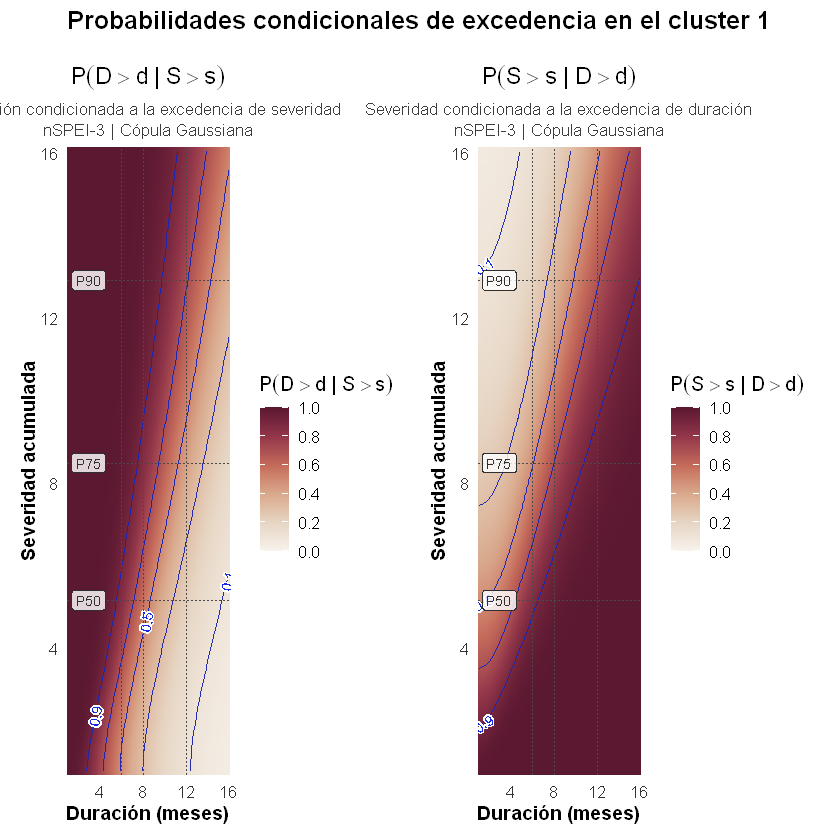

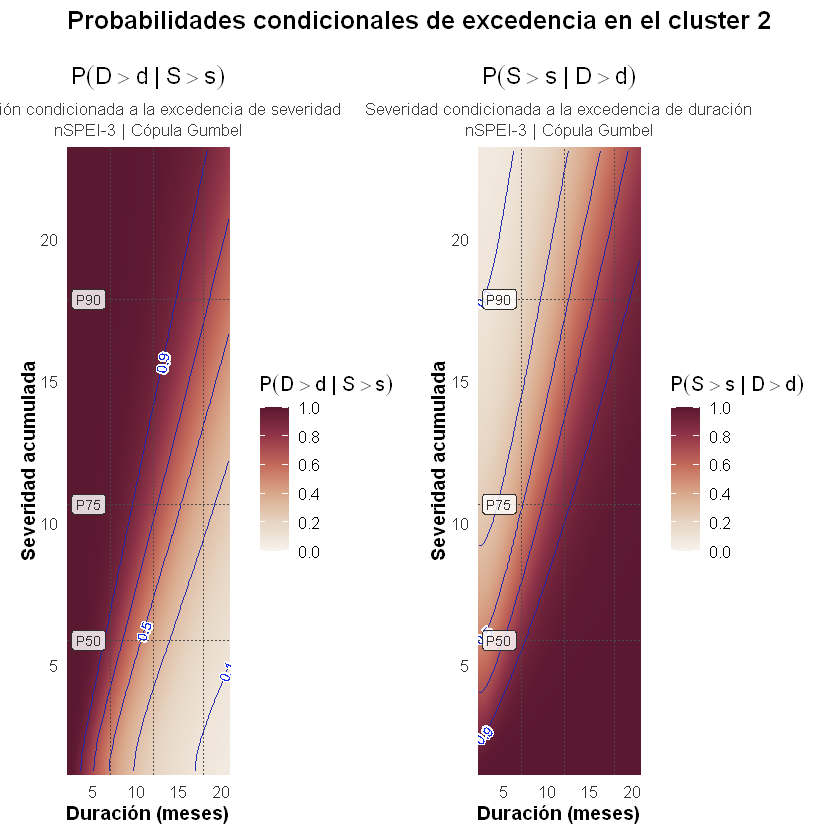

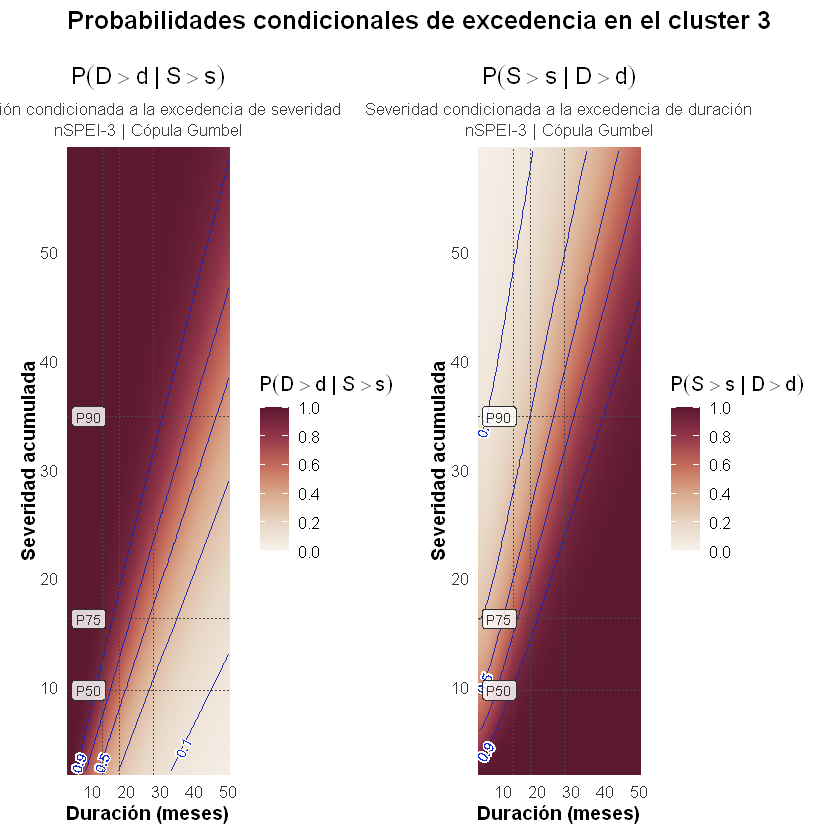

In [17]:
# ============================================================
# 12. FIGURAS 20, 21 Y 22
# ============================================================

plots <- vector("list", 3)

for (cl in 1:3) {

  familia <- modelos_cluster[[cl]]$C$familia

  p_d_s <- plot_condicional(
    mallas[[cl]],
    datos_clusters[[cl]],
    paste("Cluster", cl),
    familia,
    "p_d_s"
  )

  p_s_d <- plot_condicional(
    mallas[[cl]],
    datos_clusters[[cl]],
    paste("Cluster", cl),
    familia,
    "p_s_d"
  )

  figura <- (p_d_s | p_s_d) +
    patchwork::plot_annotation(
      title = paste0(
        "Probabilidades condicionales de excedencia en el cluster ",
        cl
      ),
      theme = theme(
        plot.title = element_text(
          face = "bold",
          size = 15,
          hjust = 0.5,
          margin = margin(b = 12)
        )
      )
    )

  plots[[cl]] <- figura

  ggsave(
    file.path(
      ruta_figuras,
      paste0(
        "figura_", 19 + cl,
        "_riesgo_condicional_cluster", cl,
        ".png"
      )
    ),
    figura,
    width = 14.5,
    height = 6.5,
    dpi = 400,
    bg = "white"
  )

  print(figura)
}


In [13]:
# ============================================================
# 13. CONTROLES NUMÉRICOS Y VERIFICACIÓN FINAL
# ============================================================

control <- condicional_all %>%
  transmute(
    cluster,
    percentil_d,
    percentil_s,
    p_joint,
    p_d,
    p_s,
    p_s_d,
    p_d_s,
    joint_valido =
      p_joint >= -1e-12 &
      p_joint <= pmin(p_d, p_s) + 1e-12,
    cond_s_d_valida =
      p_s_d >= -1e-12 &
      p_s_d <= 1 + 1e-12,
    cond_d_s_valida =
      p_d_s >= -1e-12 &
      p_d_s <= 1 + 1e-12
  )

if (
  any(!control$joint_valido) ||
  any(!control$cond_s_d_valida) ||
  any(!control$cond_d_s_valida)
) {
  stop("Se detectó una inconsistencia numérica en las probabilidades condicionales.")
}

salidas <- c(
  file.path(
    ruta_tablas,
    "riesgo_condicional_nspei3_tres_clusters.csv"
  ),
  file.path(
    ruta_tablas,
    "tabla_16_escenarios_riesgo_condicional.csv"
  ),
  file.path(
    ruta_tablas,
    "tabla_17_definicion_probabilidades_condicionales.csv"
  ),
  file.path(
    ruta_tablas,
    "tabla_18_comparacion_probabilidades_condicionales.csv"
  ),
  file.path(
    ruta_figuras,
    "figura_20_riesgo_condicional_cluster1.png"
  ),
  file.path(
    ruta_figuras,
    "figura_21_riesgo_condicional_cluster2.png"
  ),
  file.path(
    ruta_figuras,
    "figura_22_riesgo_condicional_cluster3.png"
  )
)

verificacion <- tibble(
  archivo = basename(salidas),
  existe = file.exists(salidas),
  tamaño_bytes = file.info(salidas)$size
)

cat("\n=== CONTROL P90-P90 ===\n")
print(tabla_16, n = Inf, width = Inf)

cat("\n=== COMPARACIÓN DIRECCIONAL P90-P90 ===\n")
print(tabla_18, n = Inf, width = Inf)

cat("\n=== CONTROL NUMÉRICO ===\n")
print(
  control %>%
    summarise(
      todos_joint_validos = all(joint_valido),
      todas_p_s_d_validas = all(cond_s_d_valida),
      todas_p_d_s_validas = all(cond_d_s_valida)
    )
)

cat("\n=== ARCHIVOS GENERADOS ===\n")
print(verificacion, n = Inf, width = Inf)



=== CONTROL P90-P90 ===
# A tibble: 3 × 13
  cluster     d     s dist_d dist_s copula   parametro_copula     u     v   Cuv
    <int> <dbl> <dbl> <chr>  <chr>  <chr>    <chr>            <dbl> <dbl> <dbl>
1       1  12    12.9 LN3    LN3    Gaussian rho.1=0.903663   0.891 0.895 0.861
2       2  17.9  17.9 LN3    LN3    Gumbel   alpha=3.456922   0.912 0.901 0.887
3       3  28    34.9 LN3    GPA    Gumbel   alpha=3.801567   0.863 0.911 0.857
  p_joint `P(D > d | S > s)` `P(S > s | D > d)`
    <dbl>              <dbl>              <dbl>
1  0.0750              0.714              0.685
2  0.0731              0.741              0.835
3  0.0837              0.938              0.609

=== COMPARACIÓN DIRECCIONAL P90-P90 ===
# A tibble: 3 × 7
  cluster     d     s `P(D > d | S > s)` `P(S > s | D > d)` diferencia
    <int> <dbl> <dbl>              <dbl>              <dbl>      <dbl>
1       1  12    12.9              0.714              0.685    -0.0288
2       2  17.9  17.9              0.741    